# Visualizing the branching process

ETAS is a **branching (cluster) process**: background "immigrant" events each seed a tree of
triggered descendants. The simulator records every event's `parent`, so we can reconstruct the
full forest. Here we collect the clusters and visualize one as a branching process — its
genealogy, its footprint in space, and how it grows.

Cluster tools live on `Catalog` (`cluster_roots`, `generation`, `clusters`) and in
`moment_etas.visualization.branching`. See `../spec.md` §6 for the branching simulation.

In [159]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from moment_etas import Params, simulate_catalog
from moment_etas.visualization import branching
from moment_etas.visualization import plots

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# near-critical triggering so clusters are large and multi-generation
cat = simulate_catalog(Params(mu0=2e-7, k=0.09, alpha=1.15), t_max=10000 * 365.25, seed=7)
clusters = cat.clusters()
n_bg = (cat.parent == -1).sum()
print(f"{len(cat)} events, {n_bg} background → {len(clusters)} clusters")
print(f"largest clusters: {[len(c) for c in clusters[:8]]}")

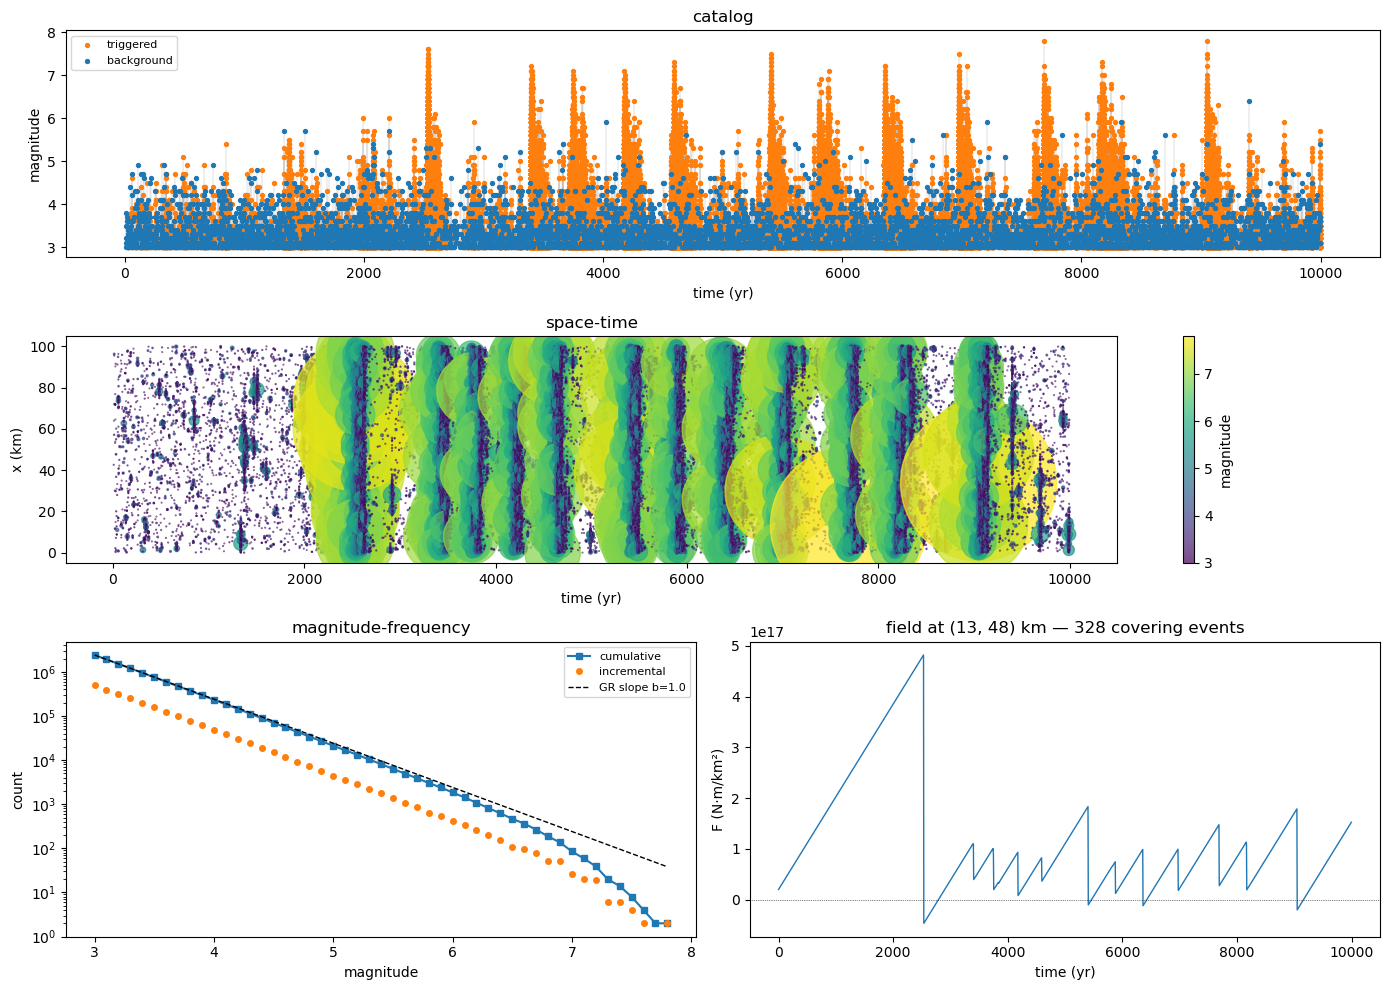

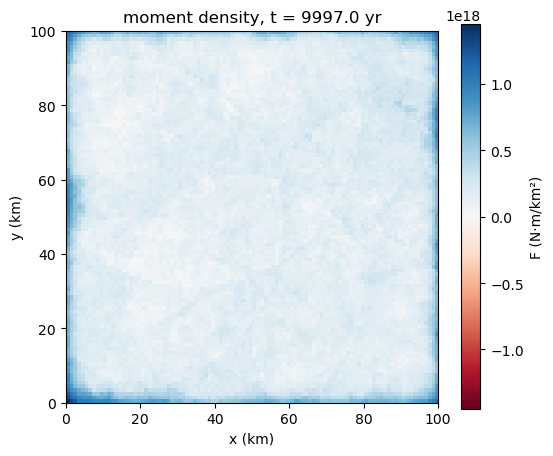

In [107]:
plots.overview(cat)
plots.field_map(cat);

## Cluster-size distribution

A branching-process signature: near criticality the cluster sizes are heavy-tailed (a few huge
families, many singletons). Log-log histogram of family sizes.

singletons (background with no offspring): 4752 (74% of clusters)


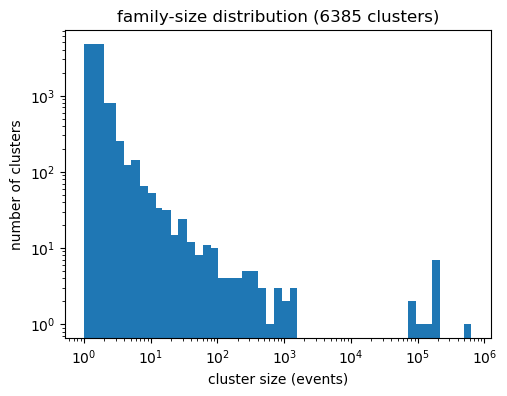

In [112]:
sizes = np.array([len(c) for c in clusters])
bins = np.unique(np.round(np.logspace(0, np.log10(sizes.max()), 50)).astype(int))

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.hist(sizes, bins=bins)
ax.set(xscale="log", yscale="log",
       xlabel="cluster size (events)", ylabel="number of clusters",
       title=f"family-size distribution ({len(clusters)} clusters)")
print(f"singletons (background with no offspring): {(sizes == 1).sum()} "
      f"({(sizes == 1).mean():.0%} of clusters)")

## Pick a cluster

For a readable family tree we want a moderate cluster (tens–low hundreds of events) with a sizable
root. The space-time map handles big clusters fine, so we also keep the largest for that.

In [ ]:
gen = cat.generation()
moderate = [c for c in clusters if 100 <= len(c) <= 600]
members = max(moderate, key=lambda c: cat.m[c[0]])      # biggest root among moderate clusters
biggest = clusters[0]

root = members[0]
print(f"chosen cluster: {len(members)} events, root M{cat.m[root]:.1f}, "
      f"{gen[members].max()} generations, "
      f"span {(cat.t[members].max() - cat.t[root]) / 365.25:.1f} yr")
print(f"largest cluster: {len(biggest)} events, {gen[biggest].max()} generations")

chosen cluster: 520 events, root M5.9, 16 generations, span 94.1 yr
largest cluster: 641220 events, 90 generations


## 1. Genealogy — the family tree

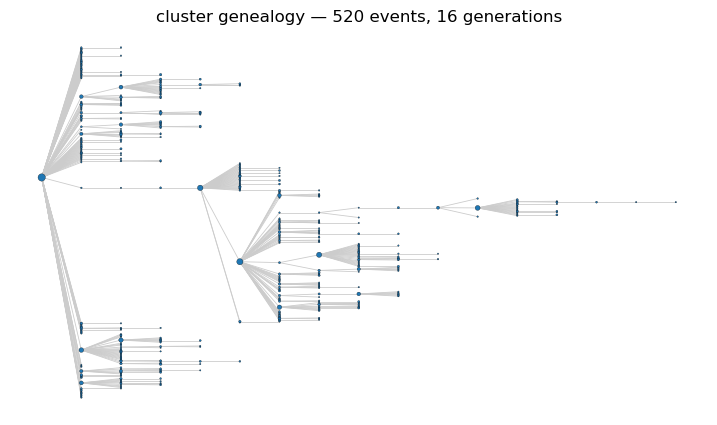

In [167]:
branching.cluster_tree(cat, members);

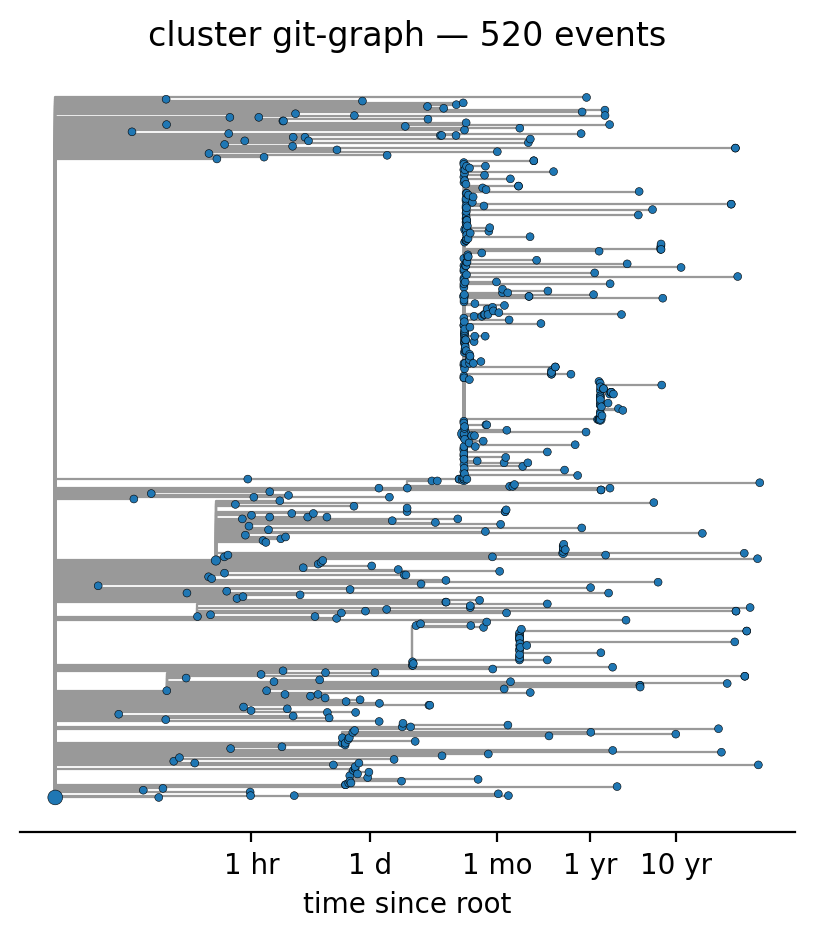

In [169]:
fig, ax = plt.subplots(figsize=(5,5), dpi=200)
branching.cluster_git(cat, members, ax);

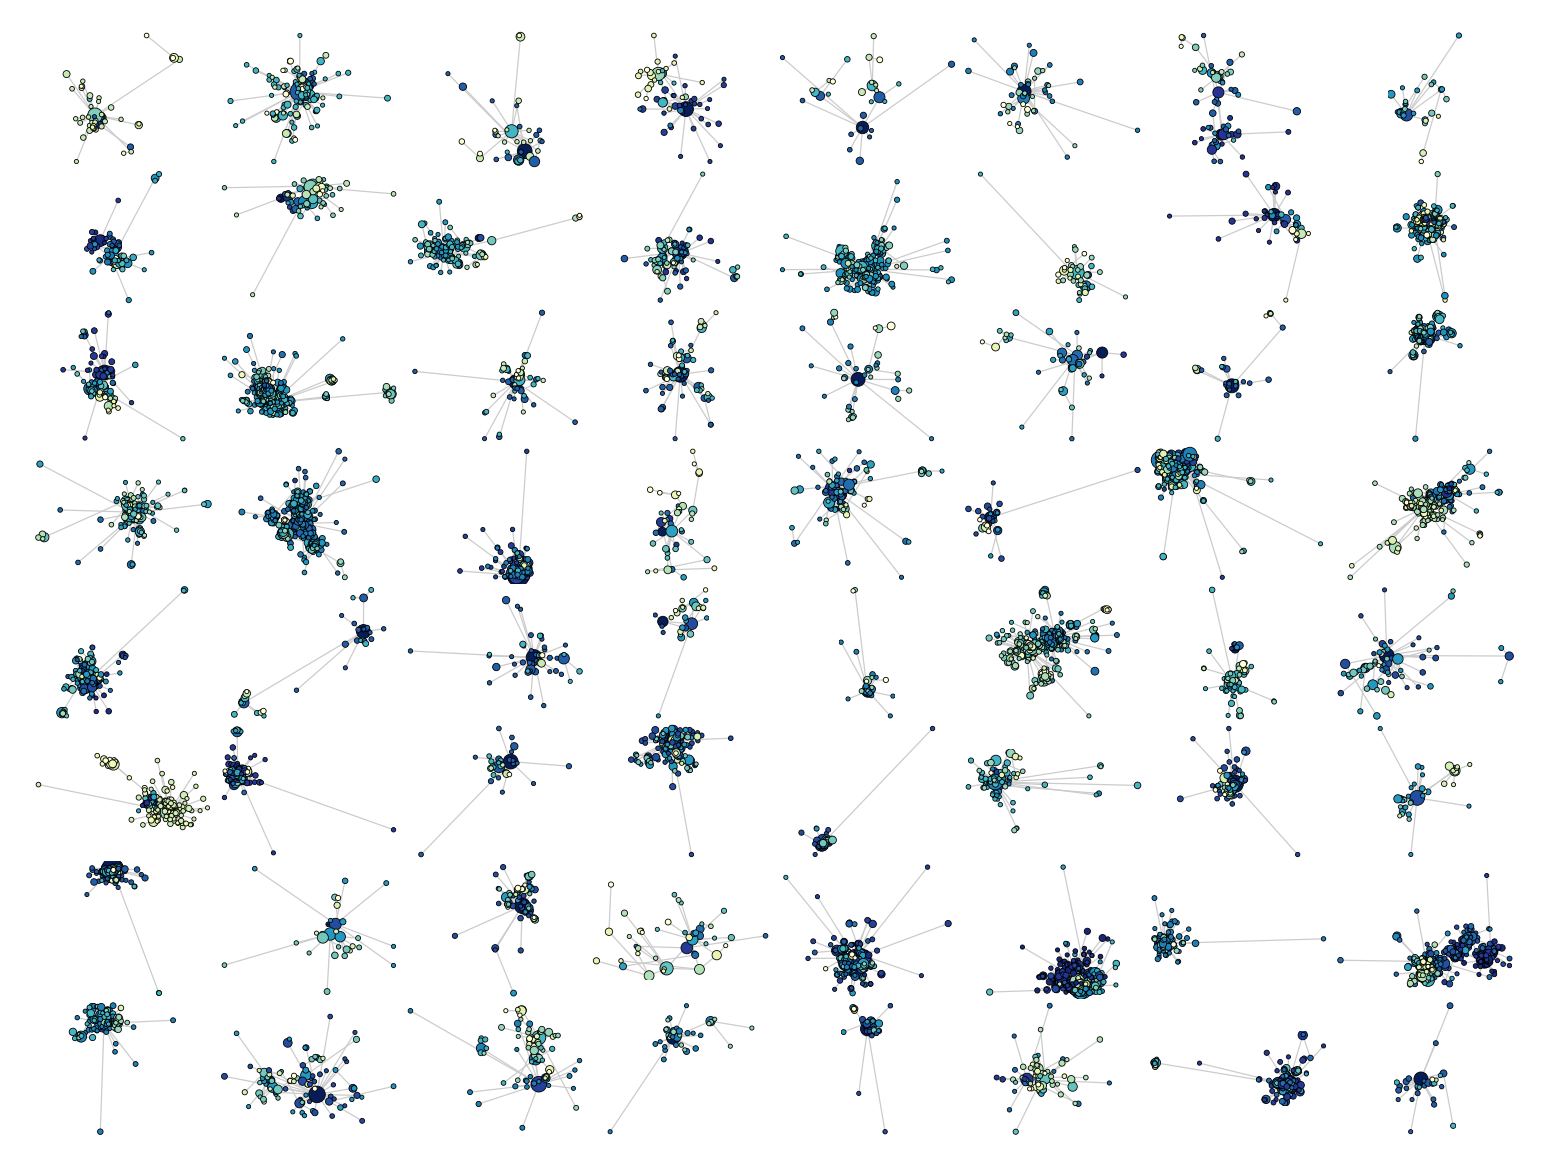

In [158]:
num_examples = 64
fig, AX = plt.subplots(
    np.int16(np.sqrt(num_examples)), np.int16(np.sqrt(num_examples)),
    dpi=300,
    gridspec_kw={"wspace": 0.0, "hspace": 0.0},
)
for ax, cluster in zip(
    AX.ravel(), [moderate[i] for i in np.random.choice(len(moderate), num_examples, replace=False)]
):
    branching.cluster_map(cat, cluster, ax)


## 3. Growth and generations

Left: cumulative events since the root (the Omori-style cascade growth). Right: events per
generation — whether the cascade builds (each generation larger, near/super-critical) before
Omori decay and field depletion damp it out.

/var/folders/nl/dmjw3blj27nd4c04v3dxnqw40000gn/T/ipykernel_26008/127138253.py:3: RuntimeWarning: invalid value encountered in log10
  dt = np.logspace(-8, np.log10(cat.t[biggest].max()-cat.t[root]), 100)


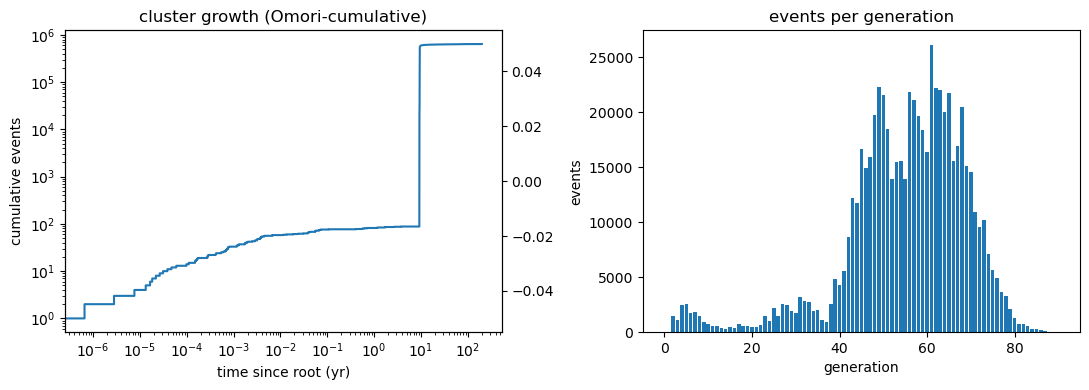

In [147]:
axes = branching.cluster_diagnostics(cat, biggest);

dt = np.logspace(-8, np.log10(cat.t[biggest].max()-cat.t[root]), 100)
mean_field = []
for tq, field in cat.iter_fields(cat.t[root]+dt):
    mean_field.append(field.field(tq).mean())
axb = axes[0].twinx()   
axb.plot(dt, mean_field, color="k")
plt.tight_layout()



[None, Text(0, 0.5, 'branching ratio')]

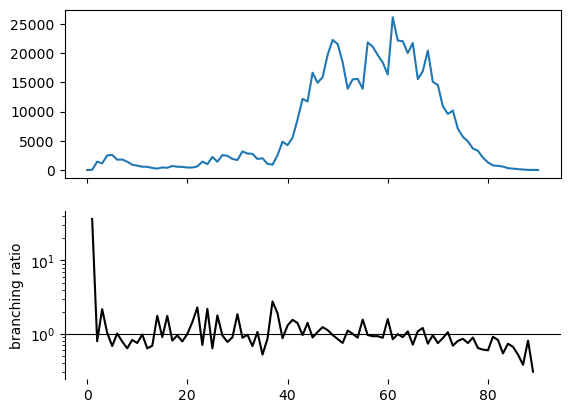

In [148]:
root, _, gen = branching._tree(cat, biggest)
g = np.array([gen[int(i)] for i in biggest])
counts = np.bincount(g)

fig, ax = plt.subplots(2,1, sharex=True)
ax[0].plot(counts)
axb = ax[1]
axb.plot(
    np.arange(len(counts) - 1)[1:], [c2 / c1 for c1, c2 in zip(counts[:-1], counts[1:])][1:],
    color="k",
)
axb.axhline(1, color="k", lw=0.8)

# remove top, right, bottom spines
axb.spines["top"].set_visible(False)
axb.spines["right"].set_visible(False)
axb.spines["bottom"].set_visible(False)

axb.set(
    yscale="log",
    ylabel="branching ratio",
)

## Notes

- **Cluster API**: `cat.clusters()` returns member-index arrays (largest first), `cat.generation()`
  the depth per event, `cat.cluster_roots()` the background ancestor. Tree edges within a cluster
  are `(cat.parent[i], i)` for non-root members.
- **Regime**: `alpha`, `k` control how branchy the clusters are; the near-critical settings here
  give deep, heavy-tailed families. Lower `k`/`alpha` → mostly singletons and shallow trees.
- **Moment coupling**: in this model a cascade also *depletes* the field, so very large families
  eventually self-limit (the core locks) — visible as the generation counts rolling over.